TypeError: _AxesBase.set_xlim() got an unexpected keyword argument 'fontsize'

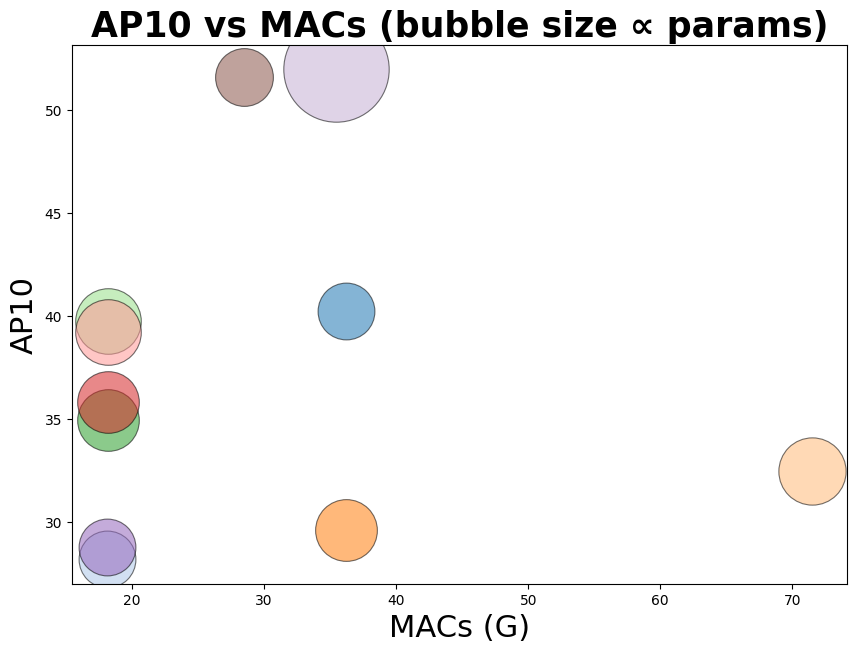

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Faltan por añadirse: 
url = "https://docs.google.com/spreadsheets/d/1FCRoQSso0D1cOMnjdgwXM45r_jAV_5qMdKh5jYK63nA/export?format=csv"
df = pd.read_csv(url)

# Falta añadir x3d_m (exp11) y luego NUESTRA MEJOR COMBINACION de clip len 100, stride 5 y alguna de las 3d cnns
df_sel = df[
    df["Experiment"].notna() &
    (df["Experiment"].astype(str).str.strip() != "")
].copy().reset_index(drop=True)

df_sel["exp_num"] = df_sel["Experiment"].str.extract(r'(\d+)').astype(int)
df_sel = df_sel.sort_values("exp_num").reset_index(drop=True)

df_sel["id"] = range(1, len(df_sel) + 1)

df_sel["TOTAL PARAMS"] = (
    df_sel["TOTAL PARAMS"].astype(str).str.replace(",", "", regex=False)
)
df_sel["TOTAL PARAMS"] = pd.to_numeric(df_sel["TOTAL PARAMS"], errors="coerce")
df_sel["MACs"] = pd.to_numeric(df_sel["MACs"], errors="coerce")
df_sel["AP10"] = pd.to_numeric(df_sel["AP10"], errors="coerce")

sizes = np.sqrt(df_sel["TOTAL PARAMS"]) 

cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(len(df_sel))]

plt.figure(figsize=(10, 7))

handles = []
labels = []

for i, row in df_sel.iterrows():
    plt.scatter(
        row["MACs"],
        row["AP10"],
        s=sizes.iloc[i],
        alpha=0.55,
        color=colors[i],
        edgecolors="black",
        linewidths=0.8
    )

plt.xlabel("MACs (G)", fontsize=22)
plt.ylabel("AP10", fontsize=22)
plt.title("AP10 vs MACs (bubble size ∝ params)", fontsize=25, fontweight='bold')

plt.xlim(0, 100)
plt.ylim(0, max(df_sel["AP10"]) + 5)

plt.grid(True, alpha=0.3)

legend_elements = []

for i, row in df_sel.iterrows():
    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=f'{row["Experiment"]}',
            markerfacecolor=colors[i],
            markersize=22 
        )
    )

plt.legend(
    handles=legend_elements,
    title="Experiments",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()